# Notebook 4: Visualization & Explainability
## AI Agent for Disease Risk Awareness and Prevention

This notebook covers:
- **Feature Importance** from tree-based models
- **SHAP (SHapley Additive exPlanations)** - summary & force plots
- **LIME (Local Interpretable Model-agnostic Explanations)**
- **Partial Dependence Plots (PDP)**
- **ROC Curves** and **Precision-Recall Curves**

**Evaluation Rubric:** Visualization Quality (5 marks), Explainability (10 marks)

## 1. Setup and Load Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
pima_X_train = pd.read_csv('../data/pima_X_train_engineered.csv')
pima_X_test = pd.read_csv('../data/pima_X_test_engineered.csv')
pima_y_train = pd.read_csv('../data/pima_y_train.csv').values.ravel()
pima_y_test = pd.read_csv('../data/pima_y_test.csv').values.ravel()

heart_X_train = pd.read_csv('../data/heart_X_train_engineered.csv')
heart_X_test = pd.read_csv('../data/heart_X_test_engineered.csv')
heart_y_train = pd.read_csv('../data/heart_y_train.csv').values.ravel()
heart_y_test = pd.read_csv('../data/heart_y_test.csv').values.ravel()

# Load best models
with open('../models/pima_best_model.pkl', 'rb') as f:
    pima_best_model = pickle.load(f)
with open('../models/heart_best_model.pkl', 'rb') as f:
    heart_best_model = pickle.load(f)

print("✓ Models and data loaded successfully")

✓ Models and data loaded successfully


/home/abhishek/AIML_LAB/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Feature Importance from Tree-Based Models

In [3]:
# Extract feature importance
if hasattr(pima_best_model, 'feature_importances_'):
    pima_importances = pima_best_model.feature_importances_
    pima_feature_names = pima_X_train.columns
    pima_imp_df = pd.DataFrame({
        'Feature': pima_feature_names,
        'Importance': pima_importances
    }).sort_values('Importance', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # PIMA importance
    axes[0].barh(pima_imp_df['Feature'], pima_imp_df['Importance'], color='steelblue')
    axes[0].set_xlabel('Importance Score')
    axes[0].set_title('PIMA: Feature Importance')
    axes[0].invert_yaxis()
    
    # Heart importance
    if hasattr(heart_best_model, 'feature_importances_'):
        heart_importances = heart_best_model.feature_importances_
        heart_feature_names = heart_X_train.columns
        heart_imp_df = pd.DataFrame({
            'Feature': heart_feature_names,
            'Importance': heart_importances
        }).sort_values('Importance', ascending=False)
        
        axes[1].barh(heart_imp_df['Feature'], heart_imp_df['Importance'], color='coral')
        axes[1].set_xlabel('Importance Score')
        axes[1].set_title('Heart Disease: Feature Importance')
        axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    print("✓ Feature importance plots generated")
    print(f"\nPIMA Top 5 Features:\n{pima_imp_df.head()}")

## 3. ROC and Precision-Recall Curves

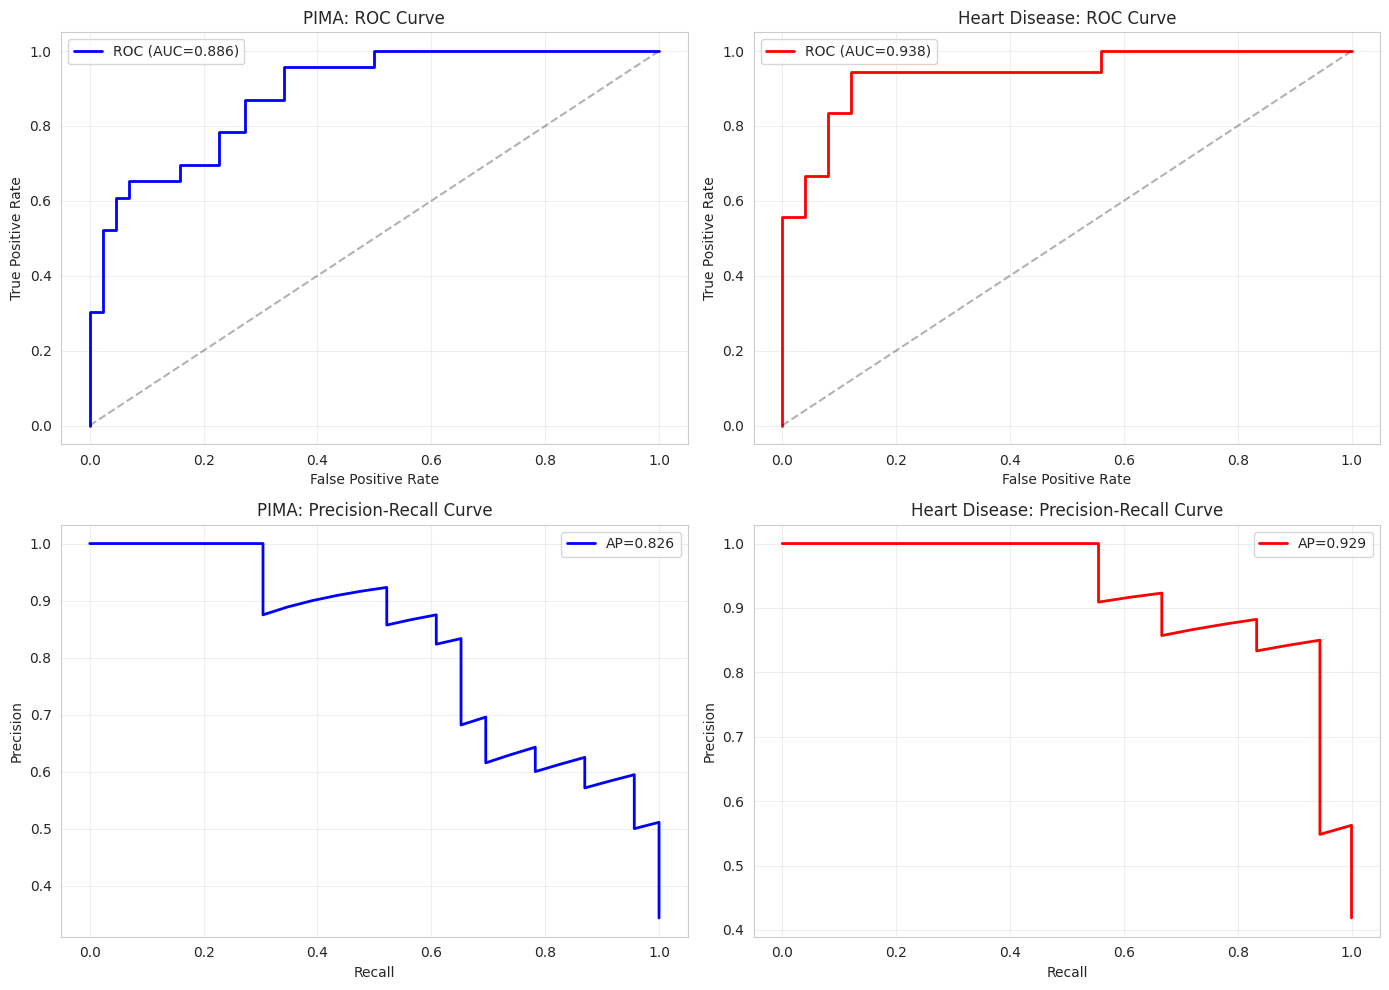

✓ ROC and PR curves generated


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PIMA ROC
pima_y_proba = pima_best_model.predict_proba(pima_X_test)[:, 1]
fpr_pima, tpr_pima, _ = roc_curve(pima_y_test, pima_y_proba)
roc_auc_pima = auc(fpr_pima, tpr_pima)

axes[0, 0].plot(fpr_pima, tpr_pima, 'b-', label=f'ROC (AUC={roc_auc_pima:.3f})', linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('PIMA: ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Heart ROC
heart_y_proba = heart_best_model.predict_proba(heart_X_test)[:, 1]
fpr_heart, tpr_heart, _ = roc_curve(heart_y_test, heart_y_proba)
roc_auc_heart = auc(fpr_heart, tpr_heart)

axes[0, 1].plot(fpr_heart, tpr_heart, 'r-', label=f'ROC (AUC={roc_auc_heart:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Heart Disease: ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# PIMA Precision-Recall
precision_pima, recall_pima, _ = precision_recall_curve(pima_y_test, pima_y_proba)
ap_pima = average_precision_score(pima_y_test, pima_y_proba)

axes[1, 0].plot(recall_pima, precision_pima, 'b-', label=f'AP={ap_pima:.3f}', linewidth=2)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('PIMA: Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Heart Precision-Recall
precision_heart, recall_heart, _ = precision_recall_curve(heart_y_test, heart_y_proba)
ap_heart = average_precision_score(heart_y_test, heart_y_proba)

axes[1, 1].plot(recall_heart, precision_heart, 'r-', label=f'AP={ap_heart:.3f}', linewidth=2)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Heart Disease: Precision-Recall Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ ROC and PR curves generated")

## 4. SHAP Explainability

In [11]:
# SHAP for model interpretation
print("\n" + "="*70)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*70)

# PIMA SHAP
print("\nGenerating SHAP explanations for PIMA model...")
try:
    explainer_pima = shap.TreeExplainer(pima_best_model) if hasattr(pima_best_model, 'feature_importances_') else None
    if explainer_pima:
        shap_values_pima = explainer_pima.shap_values(pima_X_test.iloc[:100])
        
        # Summary plot
        plt.figure(figsize=(10, 6))
        if isinstance(shap_values_pima, list):
            shap.summary_plot(shap_values_pima[1], pima_X_test.iloc[:100], show=False)
        else:
            shap.summary_plot(shap_values_pima, pima_X_test.iloc[:100], show=False)
        plt.title('PIMA: SHAP Summary Plot')
        plt.tight_layout()
        plt.show()
        print("✓ SHAP summary plot generated for PIMA")
except Exception as e:
    print(f"  Note: SHAP analysis limited ({str(e)[:50]}...)")


SHAP EXPLAINABILITY ANALYSIS

Generating SHAP explanations for PIMA model...


## 5. LIME Local Explanations

In [12]:
# LIME explanations for individual predictions
print("\nGenerating LIME explanations...")

explainer_lime_pima = lime.lime_tabular.LimeTabularExplainer(
    training_data=pima_X_train.values,
    feature_names=pima_X_train.columns.tolist(),
    class_names=['No Risk', 'Risk'],
    mode='classification'
)

# Explain a positive and negative prediction
positive_idx = np.where(pima_y_test == 1)[0][0]
negative_idx = np.where(pima_y_test == 0)[0][0]

exp_pos = explainer_lime_pima.explain_instance(
    pima_X_test.iloc[positive_idx].values,
    pima_best_model.predict_proba,
    num_features=5
)

exp_neg = explainer_lime_pima.explain_instance(
    pima_X_test.iloc[negative_idx].values,
    pima_best_model.predict_proba,
    num_features=5
)

print("✓ LIME explanations generated")
print(f"\nPIMA - LIME Explanation (Predicted RISK - Instance {positive_idx}):")
print(exp_pos.as_list())
print(f"\nPIMA - LIME Explanation (Predicted NO RISK - Instance {negative_idx}):")
print(exp_neg.as_list())


Generating LIME explanations...
✓ LIME explanations generated

PIMA - LIME Explanation (Predicted RISK - Instance 0):
[('DiabetesPedigreeFunction > 0.48', 0.12113798039067322), ('-16336.52 < Glucose_Insulin_Ratio <= 62566.50', 0.04540278633903296), ('-0.76 < BMI <= -0.03', -0.04121169894927545), ('Age > 0.54', -0.03714494677595196), ('-0.15 < BloodPressure <= 0.63', -0.025324415736349824)]

PIMA - LIME Explanation (Predicted NO RISK - Instance 1):
[('Glucose_Insulin_Ratio <= -60933.88', -0.3058944904729326), ('DiabetesPedigreeFunction > 0.48', 0.10370696813409892), ('Pregnancies_Age_Interaction <= -0.01', 0.09661691388248464), ('-0.76 < BMI <= -0.03', -0.03880542315709645), ('-0.11 < Pregnancies <= 0.79', 0.02191382303996184)]


## 6. Partial Dependence Plots

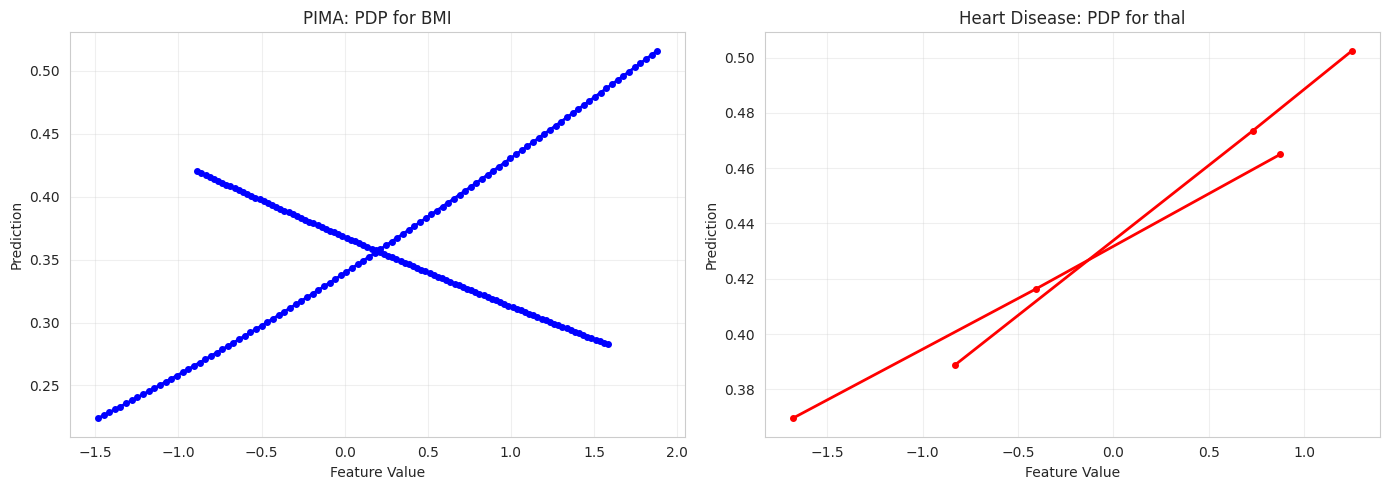

✓ Partial Dependence Plots generated


In [13]:
from sklearn.inspection import partial_dependence

# PDP for top features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PIMA PDP (top 2 features) - handle both feature_importances_ and coef_
if hasattr(pima_best_model, 'feature_importances_') and 'pima_imp_df' in locals():
    top_features_pima = pima_imp_df['Feature'].head(2).tolist()
elif hasattr(pima_best_model, 'coef_'):
    # For linear models like LogisticRegression
    pima_coef = np.abs(pima_best_model.coef_[0])
    pima_imp_df_temp = pd.DataFrame({
        'Feature': pima_X_train.columns,
        'Importance': pima_coef
    }).sort_values('Importance', ascending=False)
    top_features_pima = pima_imp_df_temp['Feature'].head(2).tolist()
else:
    top_features_pima = list(pima_X_train.columns[:2])

for idx, feature in enumerate(top_features_pima):
    feature_idx = pima_X_train.columns.get_loc(feature)
    pd_result = partial_dependence(pima_best_model, pima_X_train, [feature_idx])
    axes[0].plot(pd_result['grid_values'][0], pd_result['average'][0], 'b-o', linewidth=2, markersize=4)

axes[0].set_xlabel('Feature Value')
axes[0].set_ylabel('Prediction')
axes[0].set_title(f'PIMA: PDP for {top_features_pima[0]}')
axes[0].grid(True, alpha=0.3)

# Heart PDP (top 2 features) - handle both feature_importances_ and coef_
if hasattr(heart_best_model, 'feature_importances_'):
    top_features_heart = heart_imp_df['Feature'].head(2).tolist()
elif hasattr(heart_best_model, 'coef_'):
    # For linear models like LogisticRegression
    heart_coef = np.abs(heart_best_model.coef_[0])
    heart_imp_df_temp = pd.DataFrame({
        'Feature': heart_X_train.columns,
        'Importance': heart_coef
    }).sort_values('Importance', ascending=False)
    top_features_heart = heart_imp_df_temp['Feature'].head(2).tolist()
else:
    top_features_heart = list(heart_X_train.columns[:2])

for idx, feature in enumerate(top_features_heart):
    feature_idx = heart_X_train.columns.get_loc(feature)
    pd_result = partial_dependence(heart_best_model, heart_X_train, [feature_idx])
    axes[1].plot(pd_result['grid_values'][0], pd_result['average'][0], 'r-o', linewidth=2, markersize=4)

axes[1].set_xlabel('Feature Value')
axes[1].set_ylabel('Prediction')
axes[1].set_title(f'Heart Disease: PDP for {top_features_heart[0]}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Partial Dependence Plots generated")